In [1]:
import wget
import zipfile
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import seaborn as sns

# Download Tiny ImageNet
filename = wget.download("http://cs231n.stanford.edu/tiny-imagenet-200.zip")

# Unzip it
with zipfile.ZipFile(filename, 'r') as zip:
    zip.extractall('')

/var/folders/mh/zzgmclnd1fxddwnvkln531y80000gn/T/ipykernel_63428/3343393932.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


100% [..................................................] 248100043 / 248100043

In [2]:
# Parse class label names
labelnames = []
label2index = {}
with open('tiny-imagenet-200/wnids.txt', 'r') as f:
    lines = f.readlines()
    labelnames = [line.strip() for line in lines]
    label2index = {label: i for i, label in enumerate(labelnames)}

with open('tiny-imagenet-200/words.txt', 'r') as f:
    lines = f.readlines()
    label2words = {}
    for line in lines:
        line = line.strip()
        tokens = line.split()
        label = tokens[0]
        words = ' '.join(tokens[1:])
        label2words[label] = words
        
# print(labelnames)    # list of image labels
# print(label2index)   # a helper to convert string labels to integer labels (indices). Usage: label2index['n04067472']
# print(label2words)   # a helper to convert string labels to human-readable image labels (words). Usage: label2words['n04067472']

In [3]:
# a helper function to read images in the dataset
def _readtinyimagenet(dirpath):
    paths = Path(dirpath).glob('*/images/*.*')
    images = []
    labels = []
    for path in paths:
        labelname = path.parent.parent.stem
        label = label2index[labelname]
        with Image.open(path) as image:
            images.append(np.array(image.convert('RGB')))
            labels.append(label)
 
    return np.array(images), np.array(labels)

# Read the data set - this may take several minutes
X, Y = _readtinyimagenet('tiny-imagenet-200/train')

# print(X.shape, Y.shape)
# output should be: (100000, 64, 64, 3) (100000,)

# shuffle the indices
np.random.seed(42) # for reproducibility
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# split the indices into training and test sets
split_idx = int(0.8 * X.shape[0])
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

# create the training and test sets
X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape) 

np.save('train_images.npy', X_train)
np.save('train_labels.npy', Y_train)
np.save('test_images.npy', X_test)
np.save('test_labels.npy', Y_test)

(80000, 64, 64, 3) (80000,)
(20000, 64, 64, 3) (20000,)


In [4]:
# Later, cached images can be loaded as follows
X_train = np.load('train_images.npy')
Y_train = np.load('train_labels.npy')
X_test = np.load('test_images.npy')
Y_test = np.load('test_labels.npy')
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(80000, 64, 64, 3) (80000,) (20000, 64, 64, 3) (20000,)


In [5]:
# # Visualize the samples
# plt.figure(figsize=(25,25))
# for i in range(100):
#     idx = np.random.randint(len(X_train))
#     label = labelnames[Y_train[idx]]
#     words = label2words[label]
#     plt.subplot(10,10,i+1)
#     plt.imshow(X_train[idx])
#     plt.title(words)
#     plt.xticks([])
#     plt.yticks([])

In [6]:
height, width, channels = X_train.shape[1:]
print(height, width, channels)
print(X_train.shape)

# Revert vector-represented image back to a rank-3 tensor
# plt.imshow(np.reshape(X_train[0], (height, width, channels)))

64 64 3
(80000, 64, 64, 3)


In [7]:
# Convert image data to vectors
X_train_flat = np.reshape(X_train, (-1, width*height*channels))
X_test_flat = np.reshape(X_test, (-1, width*height*channels))
print(X_train_flat.shape, X_test_flat.shape)

(80000, 12288) (20000, 12288)


In [8]:
# convert image labels to one-hot encoding represenation
def onehot(y, k):
    probs = np.zeros((len(y),k))
    for i, p in enumerate(y):
        probs[i][p] = 1
    return probs

n_labels = len(labelnames)
Y_train_bin = onehot(Y_train, n_labels)
Y_test_bin = onehot(Y_test, n_labels)
print(Y_train.shape, Y_train_bin.shape, Y_test.shape, Y_test_bin.shape)

(80000,) (80000, 200) (20000,) (20000, 200)


### Normalization Section

#### flat/small = no normalization
#### flat2/small2 = (0, 1)
#### flat3/small3 = (-1, 1)

In [9]:
## Small subset to test since this thing takes forever
# Generate a random permutation of indices for the train and test sets
train_indices = np.random.permutation(X_train_flat.shape[0])[:10000]
test_indices = np.random.permutation(X_test_flat.shape[0])[:2000]

# Select the corresponding elements for both X and Y using the indices
X_train_flat_small = X_train_flat[train_indices]
Y_train_bin_small = Y_train_bin[train_indices]
X_test_flat_small = X_test_flat[test_indices]
Y_test_bin_small = Y_test_bin[test_indices]

In [10]:
## Normalize pixel values (between 0 and 1)

X_train_flat2 = X_train_flat / 255
X_test_flat2 = X_test_flat / 255

## Small subset to test
X_train_flat_small2 = X_train_flat2[train_indices]
Y_train_bin_small2 = Y_train_bin[train_indices]
X_test_flat_small2 = X_test_flat2[test_indices]
Y_test_bin_small2 = Y_test_bin[test_indices]

In [11]:
## Normalize pixel values (between -1 and 1)

X_train_flat3 = (X_train_flat / 128.0) - 1
X_test_flat3 = (X_test_flat / 128.0) - 1

## Small subset to test
X_train_flat_small3 = X_train_flat3[train_indices]
Y_train_bin_small3 = Y_train_bin[train_indices]
X_test_flat_small3 = X_test_flat3[test_indices]
Y_test_bin_small3 = Y_test_bin[test_indices]

## Vanilla Logistic Regression

In [32]:
class VLogisticRegression:
    def __init__(self, input_size, num_classes, learning_rate):
        self.W = np.random.randn(input_size, num_classes)
        self.b = np.zeros((1, num_classes))
        self.learning_rate = learning_rate

    def softmax(self, x):
        x = np.clip(x - np.max(x, axis=1, keepdims=True), -20, 20)  # Clip input values
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        logits = np.dot(X, self.W) + self.b
        return self.softmax(logits)

    def compute_loss(self, y_pred, y_true):
        n_samples = y_true.shape[0]
        epsilon = 1e-8
        return -np.sum(y_true * np.log(y_pred + epsilon)) / n_samples

    def accuracy(self, y_pred, y_true):
        return np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

    def train(self, X_train, Y_train, X_test, Y_test, batch_size, epochs):
        n_samples = X_train.shape[0]

        train_losses = []
        train_accuracies = []
        test_losses = []
        test_accuracies = []
        
        for epoch in range(epochs):
            for batch in range(n_samples // batch_size):
                X_batch = X_train[batch * batch_size:(batch + 1) * batch_size]
                Y_batch = Y_train[batch * batch_size:(batch + 1) * batch_size]

                y_pred = self.forward(X_batch)
                loss = self.compute_loss(y_pred, Y_batch)

                grad_W = np.dot(X_batch.T, (y_pred - Y_batch)) / batch_size
                grad_b = np.sum(y_pred - Y_batch, axis=0, keepdims=True) / batch_size

                self.W -= self.learning_rate * grad_W
                self.b -= self.learning_rate * grad_b

            # Evaluate performance at the end of each epoch
            y_train_pred = self.forward(X_train)
            train_loss = self.compute_loss(y_train_pred, Y_train)
            train_accuracy = self.accuracy(y_train_pred, Y_train)

            y_test_pred = self.forward(X_test)
            test_loss = self.compute_loss(y_test_pred, Y_test)
            test_accuracy = self.accuracy(y_test_pred, Y_test)

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)
            
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {100*train_accuracy:.4f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {100*test_accuracy:.4f}%")
        
        # Plot results
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Train Accuracy")
        plt.plot(test_accuracies, label="Test Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.suptitle("Vanilla Logistic Regression", fontsize=16)
        plt.show()

Epoch 1/100 - Train Loss: 17.9031, Train Accuracy: 1.8062%, Test Loss: 17.9359, Test Accuracy: 1.6200%
Epoch 2/100 - Train Loss: 17.7711, Train Accuracy: 2.5300%, Test Loss: 17.8771, Test Accuracy: 1.9500%
Epoch 3/100 - Train Loss: 17.7655, Train Accuracy: 2.5625%, Test Loss: 17.9009, Test Accuracy: 1.8150%
Epoch 4/100 - Train Loss: 17.7304, Train Accuracy: 2.7525%, Test Loss: 17.9323, Test Accuracy: 1.6450%
Epoch 5/100 - Train Loss: 17.6282, Train Accuracy: 3.3050%, Test Loss: 17.8813, Test Accuracy: 1.9200%
Epoch 6/100 - Train Loss: 17.6339, Train Accuracy: 3.2738%, Test Loss: 17.9178, Test Accuracy: 1.7250%
Epoch 7/100 - Train Loss: 17.4302, Train Accuracy: 4.3900%, Test Loss: 17.8442, Test Accuracy: 2.1250%
Epoch 8/100 - Train Loss: 17.5196, Train Accuracy: 3.8950%, Test Loss: 17.8650, Test Accuracy: 2.0200%
Epoch 9/100 - Train Loss: 17.3184, Train Accuracy: 4.9950%, Test Loss: 17.8436, Test Accuracy: 2.1300%
Epoch 10/100 - Train Loss: 17.2547, Train Accuracy: 5.3512%, Test Loss: 1

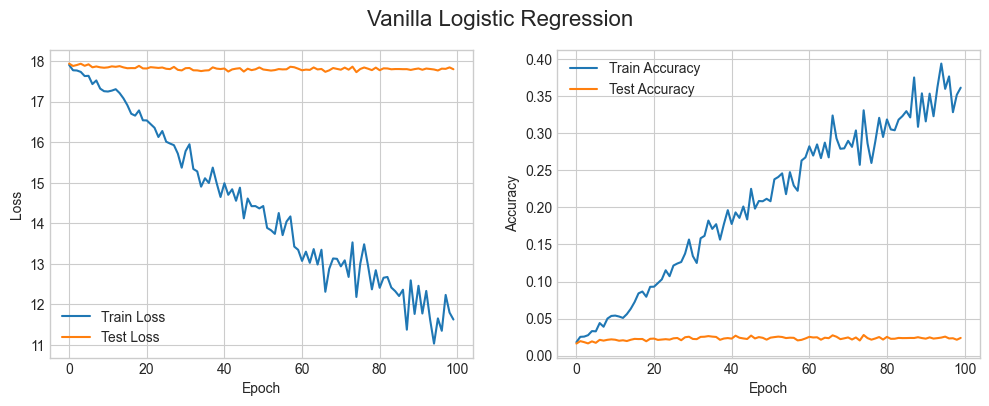

In [33]:
# No normalization
input_size = 64 * 64 * 3
learning_rate = 0.001
batch_size = 50
epochs = 100
num_classes = 200

logistic_regression = VLogisticRegression(input_size, num_classes, learning_rate)
logistic_regression.train(X_train_flat, Y_train_bin, X_test_flat, Y_test_bin, batch_size, epochs)

In [35]:
# # 0,1 normalization
# input_size = 64 * 64 * 3
# learning_rate = 0.001
# batch_size = 50
# epochs = 100
# num_classes = 200

# logistic_regression = VLogisticRegression(input_size, num_classes, learning_rate)
# logistic_regression.train(X_train_flat2, Y_train_bin, X_test_flat2, Y_test_bin, batch_size, epochs)

Epoch 1/100 - Train Loss: 18.0801, Train Accuracy: 0.5025%, Test Loss: 18.0616, Test Accuracy: 0.5600%
Epoch 2/100 - Train Loss: 18.0626, Train Accuracy: 0.5663%, Test Loss: 18.0464, Test Accuracy: 0.5800%
Epoch 3/100 - Train Loss: 18.0423, Train Accuracy: 0.6162%, Test Loss: 18.0296, Test Accuracy: 0.6500%
Epoch 4/100 - Train Loss: 18.0238, Train Accuracy: 0.6488%, Test Loss: 18.0108, Test Accuracy: 0.6700%
Epoch 5/100 - Train Loss: 18.0054, Train Accuracy: 0.6925%, Test Loss: 17.9938, Test Accuracy: 0.7300%
Epoch 6/100 - Train Loss: 17.9874, Train Accuracy: 0.7350%, Test Loss: 17.9779, Test Accuracy: 0.8000%
Epoch 7/100 - Train Loss: 17.9713, Train Accuracy: 0.7875%, Test Loss: 17.9628, Test Accuracy: 0.8850%
Epoch 8/100 - Train Loss: 17.9551, Train Accuracy: 0.8462%, Test Loss: 17.9479, Test Accuracy: 0.9400%
Epoch 9/100 - Train Loss: 17.9397, Train Accuracy: 0.8775%, Test Loss: 17.9349, Test Accuracy: 0.9250%
Epoch 10/100 - Train Loss: 17.9260, Train Accuracy: 0.9213%, Test Loss: 1

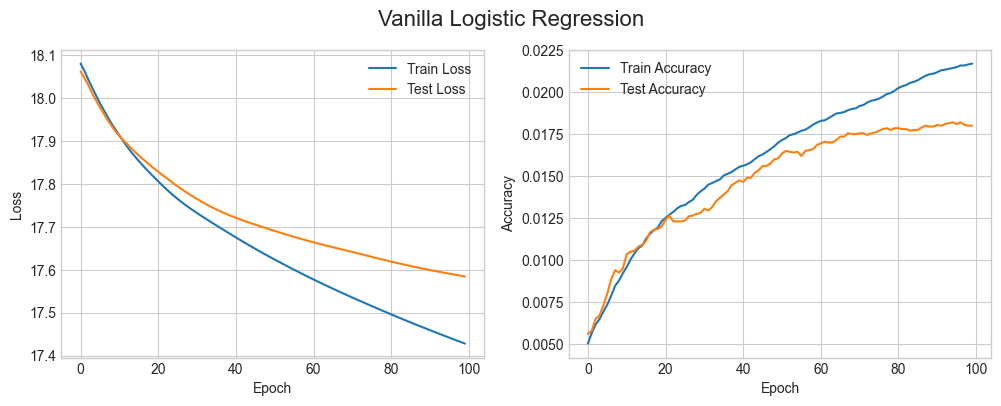

In [36]:
# -1,1 normalization
input_size = 64 * 64 * 3
learning_rate = 0.001
batch_size = 50
epochs = 100
num_classes = 200

logistic_regression = VLogisticRegression(input_size, num_classes, learning_rate)
logistic_regression.train(X_train_flat3, Y_train_bin, X_test_flat3, Y_test_bin, batch_size, epochs)

## Logistic Regression with momentum

In [37]:
class mLogisticRegression:
    def __init__(self, input_size, num_classes, learning_rate, momentum):
        self.W = np.random.randn(input_size, num_classes)
        self.b = np.zeros((1, num_classes))
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.vW = np.zeros_like(self.W)
        self.vb = np.zeros_like(self.b)

    def softmax(self, x):
        x = np.clip(x - np.max(x, axis=1, keepdims=True), -20, 20)  # Clip input values
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        logits = np.dot(X, self.W) + self.b
        return self.softmax(logits)

    def compute_loss(self, y_pred, y_true):
        n_samples = y_true.shape[0]
        epsilon = 1e-8
        return -np.sum(y_true * np.log(y_pred + epsilon)) / n_samples

    def accuracy(self, y_pred, y_true):
        return np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

    def train(self, X_train, Y_train, X_test, Y_test, batch_size, epochs):
        n_samples = X_train.shape[0]

        train_losses = []
        train_accuracies = []
        test_losses = []
        test_accuracies = []
        
        for epoch in range(epochs):
            for batch in range(n_samples // batch_size):
                X_batch = X_train[batch * batch_size:(batch + 1) * batch_size]
                Y_batch = Y_train[batch * batch_size:(batch + 1) * batch_size]

                y_pred = self.forward(X_batch)
                loss = self.compute_loss(y_pred, Y_batch)

                grad_W = np.dot(X_batch.T, (y_pred - Y_batch)) / batch_size
                grad_b = np.sum(y_pred - Y_batch, axis=0, keepdims=True) / batch_size

                self.vW = self.momentum * self.vW + self.learning_rate * grad_W
                self.vb = self.momentum * self.vb + self.learning_rate * grad_b

                self.W -= self.vW
                self.b -= self.vb

            # Evaluate performance at the end of each epoch
            y_train_pred = self.forward(X_train)
            train_loss = self.compute_loss(y_train_pred, Y_train)
            train_accuracy = self.accuracy(y_train_pred, Y_train)

            y_test_pred = self.forward(X_test)
            test_loss = self.compute_loss(y_test_pred, Y_test)
            test_accuracy = self.accuracy(y_test_pred, Y_test)
            
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {100*train_accuracy:.4f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {100*test_accuracy:.4f}%")
            
        # Plot results
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Train Accuracy")
        plt.plot(test_accuracies, label="Test Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.suptitle("Logistic Regression with Momentum", fontsize=16)
        plt.show()

Epoch 1/100 - Train Loss: 17.5795, Train Accuracy: 3.5787%, Test Loss: 17.8355, Test Accuracy: 2.1800%
Epoch 2/100 - Train Loss: 17.3451, Train Accuracy: 4.8675%, Test Loss: 17.8103, Test Accuracy: 2.3200%
Epoch 3/100 - Train Loss: 17.1930, Train Accuracy: 5.7012%, Test Loss: 17.8515, Test Accuracy: 2.0900%
Epoch 4/100 - Train Loss: 16.7483, Train Accuracy: 8.1387%, Test Loss: 17.7857, Test Accuracy: 2.4550%
Epoch 5/100 - Train Loss: 16.4888, Train Accuracy: 9.5550%, Test Loss: 17.7572, Test Accuracy: 2.6100%
Epoch 6/100 - Train Loss: 16.6077, Train Accuracy: 8.9075%, Test Loss: 17.8121, Test Accuracy: 2.3100%
Epoch 7/100 - Train Loss: 16.1535, Train Accuracy: 11.3987%, Test Loss: 17.7595, Test Accuracy: 2.5900%
Epoch 8/100 - Train Loss: 15.7643, Train Accuracy: 13.5300%, Test Loss: 17.7510, Test Accuracy: 2.6450%
Epoch 9/100 - Train Loss: 15.7922, Train Accuracy: 13.3788%, Test Loss: 17.7478, Test Accuracy: 2.6500%
Epoch 10/100 - Train Loss: 14.8363, Train Accuracy: 18.6137%, Test Los

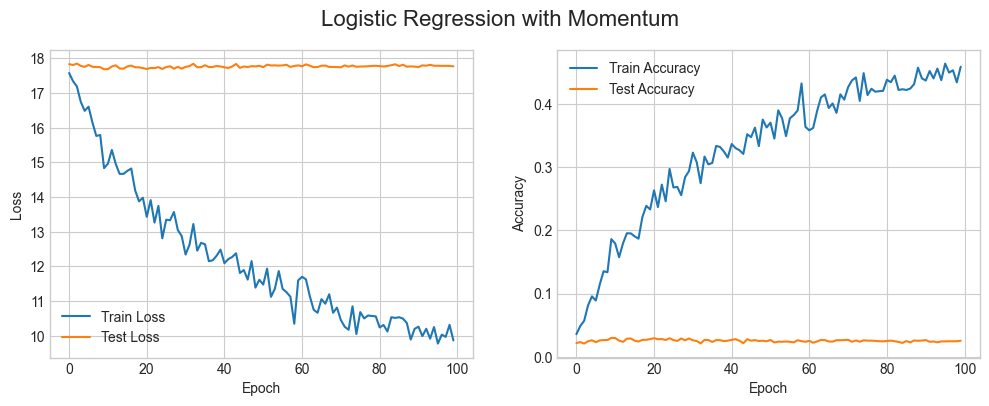

In [38]:
# No normalization
input_size = 64 * 64 * 3
learning_rate = 0.001
batch_size = 50
epochs = 100
num_classes = 200
momentum = 0.9

logistic_regression = mLogisticRegression(input_size, num_classes, learning_rate, momentum)
logistic_regression.train(X_train_flat, Y_train_bin, X_test_flat, Y_test_bin, batch_size, epochs)

In [39]:
# # 0, 1 normalization
# input_size = 64 * 64 * 3
# learning_rate = 0.001
# batch_size = 50
# epochs = 100
# num_classes = 200
# momentum = 0.9

# logistic_regression = mLogisticRegression(input_size, num_classes, learning_rate, momentum)
# logistic_regression.train(X_train_flat2, Y_train_bin, X_test_flat2, Y_test_bin, batch_size, epochs)

Epoch 1/100 - Train Loss: 17.9365, Train Accuracy: 0.8962%, Test Loss: 17.9398, Test Accuracy: 0.8850%
Epoch 2/100 - Train Loss: 17.8298, Train Accuracy: 1.1450%, Test Loss: 17.8605, Test Accuracy: 1.1700%
Epoch 3/100 - Train Loss: 17.7563, Train Accuracy: 1.3362%, Test Loss: 17.8101, Test Accuracy: 1.3050%
Epoch 4/100 - Train Loss: 17.7011, Train Accuracy: 1.4863%, Test Loss: 17.7675, Test Accuracy: 1.3850%
Epoch 5/100 - Train Loss: 17.6536, Train Accuracy: 1.6213%, Test Loss: 17.7372, Test Accuracy: 1.4800%
Epoch 6/100 - Train Loss: 17.6099, Train Accuracy: 1.7200%, Test Loss: 17.7111, Test Accuracy: 1.5650%
Epoch 7/100 - Train Loss: 17.5679, Train Accuracy: 1.8288%, Test Loss: 17.6865, Test Accuracy: 1.5550%
Epoch 8/100 - Train Loss: 17.5286, Train Accuracy: 1.9475%, Test Loss: 17.6641, Test Accuracy: 1.6100%
Epoch 9/100 - Train Loss: 17.4915, Train Accuracy: 2.0375%, Test Loss: 17.6453, Test Accuracy: 1.6150%
Epoch 10/100 - Train Loss: 17.4568, Train Accuracy: 2.1488%, Test Loss: 1

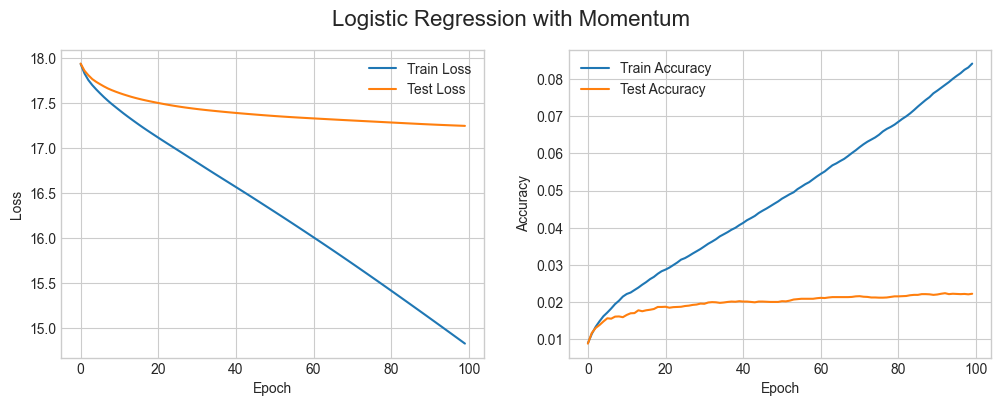

In [40]:
# -1, 1 normalization
input_size = 64 * 64 * 3
learning_rate = 0.001
batch_size = 50
epochs = 100
num_classes = 200
momentum = 0.9

logistic_regression = mLogisticRegression(input_size, num_classes, learning_rate, momentum)
logistic_regression.train(X_train_flat3, Y_train_bin, X_test_flat3, Y_test_bin, batch_size, epochs)

## Logistic Regression with ADAM

In [ ]:
import autograd.numpy as np
from autograd import grad

class aLogisticRegression:
    def __init__(self, input_size, num_classes, learning_rate):
        self.W = np.random.randn(input_size, num_classes)
        self.b = np.zeros((1, num_classes))
        self.learning_rate = learning_rate

        # ADAM optimizer parameters
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.epsilon = 1e-8
        self.mW = np.zeros_like(self.W)
        self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b)
        self.vb = np.zeros_like(self.b)

    def softmax(self, x):
        x = np.clip(x - np.max(x, axis=1, keepdims=True), -20, 20)  # Clip input values
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        logits = np.dot(X, self.W) + self.b
        return self.softmax(logits)

    def compute_loss(self, X, Y):
        y_pred = self.forward(X)
        n_samples = Y.shape[0]
        epsilon = 1e-8
        return -np.sum(Y * np.log(y_pred + epsilon)) / n_samples

    def accuracy(self, X, Y):
        y_pred = self.forward(X)
        return np.mean(np.argmax(y_pred, axis=1) == np.argmax(Y, axis=1))

    def train(self, X_train, Y_train, X_test, Y_test, batch_size, epochs):
        n_samples = X_train.shape[0]

        train_losses = []
        train_accuracies = []
        test_losses = []
        test_accuracies = []
        
        for epoch in range(epochs):
            for batch in range(n_samples // batch_size):
                X_batch = X_train[batch * batch_size:(batch + 1) * batch_size]
                Y_batch = Y_train[batch * batch_size:(batch + 1) * batch_size]

                y_pred = self.forward(X_batch)
                loss = self.compute_loss(X_batch, Y_batch)

                grad_W = np.dot(X_batch.T, (y_pred - Y_batch)) / batch_size
                grad_b = np.sum(y_pred - Y_batch, axis=0, keepdims=True) / batch_size

                # ADAM update for weights
                self.mW = self.beta1 * self.mW + (1 - self.beta1) * grad_W
                self.vW = self.beta2 * self.vW + (1 - self.beta2) * (grad_W * grad_W)
                mW_hat = self.mW / (1 - np.power(self.beta1, epoch + 1))
                vW_hat = self.vW / (1 - np.power(self.beta2, epoch + 1))
                self.W -= self.learning_rate * mW_hat / (np.sqrt(vW_hat) + self.epsilon)

                # ADAM update for biases
                self.mb = self.beta1 * self.mb + (1 - self.beta1) * grad_b
                self.vb = self.beta2 * self.vb + (1 - self.beta2) * (grad_b * grad_b)
                mb_hat = self.mb / (1 - np.power(self.beta1, epoch + 1))
                vb_hat = self.vb / (1 - np.power(self.beta2, epoch + 1))
                self.b -= self.learning_rate * mb_hat / (np.sqrt(vb_hat) + self.epsilon)

            # Evaluate performance at the end of each epoch
            y_train_pred = self.forward(X_train)
            train_loss = self.compute_loss(X_train, Y_train)
            train_accuracy = self.accuracy(X_train, Y_train)

            y_test_pred = self.forward(X_test)
            test_loss = self.compute_loss(X_test, Y_test)
            test_accuracy = self.accuracy(X_test, Y_test)
            
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {100*train_accuracy:.4f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {100*test_accuracy:.4f}%")
            
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Train Accuracy")
        plt.plot(test_accuracies, label="Test Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.suptitle("Logistic Regression with ADAM", fontsize=16)
        plt.show()

In [ ]:
# No normalization
input_size = 64*64*3
num_classes = 200
learning_rate = 0.001
batch_size = 50
epochs = 100

logistic_regression = aLogisticRegression(input_size, num_classes, learning_rate)
logistic_regression.train(X_train_flat, Y_train_bin, X_test_flat, Y_test_bin, batch_size, epochs)

In [ ]:
# # 0, 1 normalization
# input_size = 64*64*3
# num_classes = 200
# learning_rate = 0.001
# batch_size = 50
# epochs = 100

# logistic_regression = aLogisticRegression(input_size, num_classes, learning_rate)
# logistic_regression.train(X_train_flat2, Y_train_bin, X_test_flat2, Y_test_bin, batch_size, epochs)

In [ ]:
# -1, 1 normalization
input_size = 64*64*3
num_classes = 200
learning_rate = 0.001
batch_size = 50
epochs = 100

logistic_regression = aLogisticRegression(input_size, num_classes, learning_rate)
logistic_regression.train(X_train_flat3, Y_train_bin, X_test_flat3, Y_test_bin, batch_size, epochs)

## 3 Layer ANN with ADAM and L2 Regularization

In [41]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = np.clip(x - np.max(x, axis=1, keepdims=True), -20, 20)  # Clip input values
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred, model, l2_lambda):
    '''
    cross entropy loss with L2 regularization
    element wise product of log(predicted probabilities) and true labels; summed; negated
    each weight squared, summed, multiplied by (0.5*L2 value)
    cross entropy term plus L2 loss term = final loss value
    '''
    n_samples = y_true.shape[0]
    ce_loss = -np.sum(np.log(y_pred) * y_true) / n_samples
    l2_loss = 0.5 * l2_lambda * (np.sum(np.square(model.W1)) + np.sum(np.square(model.W2)) + np.sum(np.square(model.W3)) + np.sum(np.square(model.W4)))
    return ce_loss + l2_loss

class ThreeLayerNN:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda, beta1=0.9, beta2=0.999, epsilon=1e-8):
        # setting initial weight values randomly, multiplying by 0.01 to scale down
        # could try different initialization methods (He, Xavier/Glorot, etc.)
        self.W1 = np.random.randn(input_size, hidden_size_1) * 0.01
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
        self.b2 = np.zeros((1, hidden_size_2))
        self.W3 = np.random.randn(hidden_size_2, hidden_size_3) * 0.01
        self.b3 = np.zeros((1, hidden_size_3))
        self.W4 = np.random.randn(hidden_size_3, output_size) * 0.01
        self.b4 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        # initialize first (mean) and second (variance) moment estimates for Adam
        # keeping track of running average, updates the weights/biases more efficiently than vanilla gradient descent
        self.mW1, self.mb1, self.mW2, self.mb2, self.mW3, self.mb3, self.mW4, self.mb4 = [np.zeros_like(x) for x in [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]]
        self.vW1, self.vb1, self.vW2, self.vb2, self.vW3, self.vb3, self.vW4, self.vb4 = [np.zeros_like(x) for x in [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]]

    def forward(self, X):
        # forward pass, input is multiplied by weight then bias is added, repeated per layer
        # stores each value for use in the backward pass
        self.A0 = X
        self.Z1 = np.dot(self.A0, self.W1) + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = relu(self.Z3)
        self.Z4 = np.dot(self.A3, self.W4) + self.b4
        self.A4 = softmax(self.Z4)
        return self.A4

    def backward(self, X, y_true):
        # calculates error, then dot product of transposed weights and error divided by size of mini batch
        # per layer
        # then updates the weights (subject to L2 regularlization) and biases
        # and returns the gradients with respect to weights and biases (partial derivatives)
        m = X.shape[0]
        dZ4 = self.A4 - y_true
        dW4 = np.dot(self.A3.T, dZ4) / m
        db4 = np.sum(dZ4, axis=0, keepdims=True) / m
        dA3 = np.dot(dZ4, self.W4.T)
        dZ3 = dA3 * relu_derivative(self.Z3)
        dW3 = np.dot(self.A2.T, dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(self.A0.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        dW1 += self.l2_lambda * self.W1
        dW2 += self.l2_lambda * self.W2
        dW3 += self.l2_lambda * self.W3
        dW4 += self.l2_lambda * self.W4

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W4 -= self.learning_rate * dW4
        self.b4 -= self.learning_rate * db4
        return dW1, db1, dW2, db2, dW3, db3, dW4, db4

    def update_parameters_adam(self, dW1, db1, dW2, db2, dW3, db3, dW4, db4, t):
        # update biased first moment estimates
        self.mW1 = self.beta1 * self.mW1 + (1 - self.beta1) * dW1
        self.mb1 = self.beta1 * self.mb1 + (1 - self.beta1) * db1
        self.mW2 = self.beta1 * self.mW2 + (1 - self.beta1) * dW2
        self.mb2 = self.beta1 * self.mb2 + (1 - self.beta1) * db2
        self.mW3 = self.beta1 * self.mW3 + (1 - self.beta1) * dW3
        self.mb3 = self.beta1 * self.mb3 + (1 - self.beta1) * db3
        self.mW4 = self.beta1 * self.mW4 + (1 - self.beta1) * dW4
        self.mb4 = self.beta1 * self.mb4 + (1 - self.beta1) * db4

        # update biased second moment estimates
        self.vW1 = self.beta2 * self.vW1 + (1 - self.beta2) * (dW1**2)
        self.vb1 = self.beta2 * self.vb1 + (1 - self.beta2) * (db1**2)
        self.vW2 = self.beta2 * self.vW2 + (1 - self.beta2) * (dW2**2)
        self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (db2**2)
        self.vW3 = self.beta2 * self.vW3 + (1 - self.beta2) * (dW3**2)
        self.vb3 = self.beta2 * self.vb3 + (1 - self.beta2) * (db3**2)
        self.vW4 = self.beta2 * self.vW4 + (1 - self.beta2) * (dW4**2)
        self.vb4 = self.beta2 * self.vb4 + (1 - self.beta2) * (db4**2)

        # compute bias-corrected first moment estimates
        mW1_corr = self.mW1 / (1 - self.beta1**t)
        mb1_corr = self.mb1 / (1 - self.beta1**t)
        mW2_corr = self.mW2 / (1 - self.beta1**t)
        mb2_corr = self.mb2 / (1 - self.beta1**t)
        mW3_corr = self.mW3 / (1 - self.beta1**t)
        mb3_corr = self.mb3 / (1 - self.beta1**t)
        mW4_corr = self.mW4 / (1 - self.beta1**t)
        mb4_corr = self.mb4 / (1 - self.beta1**t)

        # compute bias-corrected second moment estimates
        vW1_corr = self.vW1 / (1 - self.beta2**t)
        vb1_corr = self.vb1 / (1 - self.beta2**t)
        vW2_corr = self.vW2 / (1 - self.beta2**t)
        vb2_corr = self.vb2 / (1 - self.beta2**t)
        vW3_corr = self.vW3 / (1 - self.beta2**t)
        vb3_corr = self.vb3 / (1 - self.beta2**t)
        vW4_corr = self.vW4 / (1 - self.beta2**t)
        vb4_corr = self.vb4 / (1 - self.beta2**t)
    
    def train(self, X, y, X_test, y_test, epochs, batch_size):
        train_losses = []
        train_accuracies = []
        test_losses = []
        test_accuracies = []
        for epoch in range(epochs):
            n_samples = X.shape[0]
            n_batches = n_samples // batch_size
            for i in range(n_batches):
                start = i * batch_size
                end = (i + 1) * batch_size
                X_batch = X[start:end]
                y_batch = y[start:end]
                y_pred = self.forward(X_batch)
                dW1, db1, dW2, db2, dW3, db3, dW4, db4 = self.backward(X_batch, y_batch)

                # update parameters using ADAM
                self.update_parameters_adam(dW1, db1, dW2, db2, dW3, db3, dW4, db4, epoch * n_batches + i + 1)

            y_pred_train = self.forward(X)
            train_loss = cross_entropy_loss(y, y_pred_train, self, self.l2_lambda)
            train_accuracy = np.mean(np.argmax(y, axis=1) == np.argmax(y_pred_train, axis=1))

            y_pred_test = self.forward(X_test)
            test_loss = cross_entropy_loss(y_test, y_pred_test, self, self.l2_lambda)
            test_accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_pred_test, axis=1))

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {100*train_accuracy:.4f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {100*test_accuracy:.4f}%")

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Train Accuracy")
        plt.plot(test_accuracies, label="Test Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.suptitle("Three-Layer Neural Network", fontsize=16)
        plt.show()


In [ ]:
# No normalization
input_size = X_train_flat.shape[1]
hidden_size_1 = 512
hidden_size_2 = 256
hidden_size_3 = 128
output_size = Y_test_bin.shape[1]
learning_rate = 0.001
l2_lambda = 0.001
epochs = 100
batch_size = 50

model = ThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
model.train(X_train_flat, Y_train_bin, X_test_flat, Y_test_bin, epochs, batch_size)


In [ ]:
# # 0, 1 normalization
# input_size = X_train_flat.shape[1]
# hidden_size_1 = 512
# hidden_size_2 = 256
# hidden_size_3 = 128
# output_size = Y_test_bin.shape[1]
# learning_rate = 0.001
# l2_lambda = 0.001
# epochs = 100
# batch_size = 50

# model = ThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
# model.train(X_train_flat2, Y_train_bin, X_test_flat2, Y_test_bin, epochs, batch_size)


In [ ]:
# -1, 1 normalization
input_size = X_train_flat.shape[1]
hidden_size_1 = 512
hidden_size_2 = 256
hidden_size_3 = 128
output_size = Y_test_bin.shape[1]
learning_rate = 0.001
l2_lambda = 0.001
epochs = 100
batch_size = 50

model = ThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
model.train(X_train_flat3, Y_train_bin, X_test_flat3, Y_test_bin, epochs, batch_size)


## 3 Layer NN with ADAM, L2 Regularization, and He Initialization

In [42]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = np.clip(x - np.max(x, axis=1, keepdims=True), -20, 20)  # Clip input values
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred, model, l2_lambda):
    '''
    cross entropy loss with L2 regularization
    element wise product of log(predicted probabilities) and true labels; summed; negated
    each weight squared, summed, multiplied by (0.5*L2 value)
    cross entropy term plus L2 loss term = final loss value
    '''
    n_samples = y_true.shape[0]
    ce_loss = -np.sum(np.log(y_pred) * y_true) / n_samples
    l2_loss = 0.5 * l2_lambda * (np.sum(np.square(model.W1)) + np.sum(np.square(model.W2)) + np.sum(np.square(model.W3)) + np.sum(np.square(model.W4)))
    return ce_loss + l2_loss

class heThreeLayerNN:
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda, beta1=0.9, beta2=0.999, epsilon=1e-8):
        # Initialize weights using He Initialization
        self.W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2.0 / hidden_size_1)
        self.b2 = np.zeros((1, hidden_size_2))
        self.W3 = np.random.randn(hidden_size_2, hidden_size_3) * np.sqrt(2.0 / hidden_size_2)
        self.b3 = np.zeros((1, hidden_size_3))
        self.W4 = np.random.randn(hidden_size_3, output_size) * np.sqrt(2.0 / hidden_size_3)
        self.b4 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        # initialize first (mean) and second (variance) moment estimates for Adam
        # keeping track of running average, updates the weights/biases more efficiently than vanilla gradient descent
        self.mW1, self.mb1, self.mW2, self.mb2, self.mW3, self.mb3, self.mW4, self.mb4 = [np.zeros_like(x) for x in [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]]
        self.vW1, self.vb1, self.vW2, self.vb2, self.vW3, self.vb3, self.vW4, self.vb4 = [np.zeros_like(x) for x in [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]]

    def forward(self, X):
        # forward pass, input is multiplied by weight then bias is added, repeated per layer
        # stores each value for use in the backward pass
        self.A0 = X
        self.Z1 = np.dot(self.A0, self.W1) + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = relu(self.Z3)
        self.Z4 = np.dot(self.A3, self.W4) + self.b4
        self.A4 = softmax(self.Z4)
        return self.A4

    def backward(self, X, y_true):
        # calculates error, then dot product of transposed weights and error divided by size of mini batch
        # per layer
        # then updates the weights (subject to L2 regularlization) and biases
        # and returns the gradients with respect to weights and biases (partial derivatives)
        m = X.shape[0]
        dZ4 = self.A4 - y_true
        dW4 = np.dot(self.A3.T, dZ4) / m
        db4 = np.sum(dZ4, axis=0, keepdims=True) / m
        dA3 = np.dot(dZ4, self.W4.T)
        dZ3 = dA3 * relu_derivative(self.Z3)
        dW3 = np.dot(self.A2.T, dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(self.A0.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        dW1 += self.l2_lambda * self.W1
        dW2 += self.l2_lambda * self.W2
        dW3 += self.l2_lambda * self.W3
        dW4 += self.l2_lambda * self.W4

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W4 -= self.learning_rate * dW4
        self.b4 -= self.learning_rate * db4
        return dW1, db1, dW2, db2, dW3, db3, dW4, db4

    def update_parameters_adam(self, dW1, db1, dW2, db2, dW3, db3, dW4, db4, t):
        # update biased first moment estimates
        self.mW1 = self.beta1 * self.mW1 + (1 - self.beta1) * dW1
        self.mb1 = self.beta1 * self.mb1 + (1 - self.beta1) * db1
        self.mW2 = self.beta1 * self.mW2 + (1 - self.beta1) * dW2
        self.mb2 = self.beta1 * self.mb2 + (1 - self.beta1) * db2
        self.mW3 = self.beta1 * self.mW3 + (1 - self.beta1) * dW3
        self.mb3 = self.beta1 * self.mb3 + (1 - self.beta1) * db3
        self.mW4 = self.beta1 * self.mW4 + (1 - self.beta1) * dW4
        self.mb4 = self.beta1 * self.mb4 + (1 - self.beta1) * db4

        # update biased second moment estimates
        self.vW1 = self.beta2 * self.vW1 + (1 - self.beta2) * (dW1**2)
        self.vb1 = self.beta2 * self.vb1 + (1 - self.beta2) * (db1**2)
        self.vW2 = self.beta2 * self.vW2 + (1 - self.beta2) * (dW2**2)
        self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (db2**2)
        self.vW3 = self.beta2 * self.vW3 + (1 - self.beta2) * (dW3**2)
        self.vb3 = self.beta2 * self.vb3 + (1 - self.beta2) * (db3**2)
        self.vW4 = self.beta2 * self.vW4 + (1 - self.beta2) * (dW4**2)
        self.vb4 = self.beta2 * self.vb4 + (1 - self.beta2) * (db4**2)

        # compute bias-corrected first moment estimates
        mW1_corr = self.mW1 / (1 - self.beta1**t)
        mb1_corr = self.mb1 / (1 - self.beta1**t)
        mW2_corr = self.mW2 / (1 - self.beta1**t)
        mb2_corr = self.mb2 / (1 - self.beta1**t)
        mW3_corr = self.mW3 / (1 - self.beta1**t)
        mb3_corr = self.mb3 / (1 - self.beta1**t)
        mW4_corr = self.mW4 / (1 - self.beta1**t)
        mb4_corr = self.mb4 / (1 - self.beta1**t)

        # compute bias-corrected second moment estimates
        vW1_corr = self.vW1 / (1 - self.beta2**t)
        vb1_corr = self.vb1 / (1 - self.beta2**t)
        vW2_corr = self.vW2 / (1 - self.beta2**t)
        vb2_corr = self.vb2 / (1 - self.beta2**t)
        vW3_corr = self.vW3 / (1 - self.beta2**t)
        vb3_corr = self.vb3 / (1 - self.beta2**t)
        vW4_corr = self.vW4 / (1 - self.beta2**t)
        vb4_corr = self.vb4 / (1 - self.beta2**t)
    
    def train(self, X, y, X_test, y_test, epochs, batch_size):
        train_losses = []
        train_accuracies = []
        test_losses = []
        test_accuracies = []
        for epoch in range(epochs):
            n_samples = X.shape[0]
            n_batches = n_samples // batch_size
            for i in range(n_batches):
                start = i * batch_size
                end = (i + 1) * batch_size
                X_batch = X[start:end]
                y_batch = y[start:end]
                y_pred = self.forward(X_batch)
                dW1, db1, dW2, db2, dW3, db3, dW4, db4 = self.backward(X_batch, y_batch)

                # update parameters using ADAM
                self.update_parameters_adam(dW1, db1, dW2, db2, dW3, db3, dW4, db4, epoch * n_batches + i + 1)

            y_pred_train = self.forward(X)
            train_loss = cross_entropy_loss(y, y_pred_train, self, self.l2_lambda)
            train_accuracy = np.mean(np.argmax(y, axis=1) == np.argmax(y_pred_train, axis=1))

            y_pred_test = self.forward(X_test)
            test_loss = cross_entropy_loss(y_test, y_pred_test, self, self.l2_lambda)
            test_accuracy = np.mean(np.argmax(y_test, axis=1) == np.argmax(y_pred_test, axis=1))

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            test_losses.append(test_loss)
            test_accuracies.append(test_accuracy)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {100*train_accuracy:.4f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {100*test_accuracy:.4f}%")

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Train Accuracy")
        plt.plot(test_accuracies, label="Test Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.suptitle("Three-Layer Neural Network", fontsize=16)
        plt.show()


In [43]:
# No normalization
input_size = X_train_flat.shape[1]
hidden_size_1 = 512
hidden_size_2 = 256
hidden_size_3 = 128
output_size = Y_test_bin.shape[1]
learning_rate = 0.001
l2_lambda = 0.001
epochs = 100
batch_size = 50

model = heThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
model.train(X_train_flat, Y_train_bin, X_test_flat, Y_test_bin, epochs, batch_size)

/var/folders/mh/zzgmclnd1fxddwnvkln531y80000gn/T/ipykernel_63428/2198961286.py:78: RuntimeWarning: invalid value encountered in multiply
  dZ1 = dA1 * relu_derivative(self.Z1)
/var/folders/mh/zzgmclnd1fxddwnvkln531y80000gn/T/ipykernel_63428/2198961286.py:112: RuntimeWarning: overflow encountered in square
  self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (db2**2)
/var/folders/mh/zzgmclnd1fxddwnvkln531y80000gn/T/ipykernel_63428/2198961286.py:113: RuntimeWarning: overflow encountered in square
  self.vW3 = self.beta2 * self.vW3 + (1 - self.beta2) * (dW3**2)


KeyboardInterrupt: 

Epoch 1/100 - Train Loss: 6.3674, Train Accuracy: 1.0112%, Test Loss: 6.3708, Test Accuracy: 0.8000%
Epoch 2/100 - Train Loss: 6.3373, Train Accuracy: 1.4988%, Test Loss: 6.3416, Test Accuracy: 1.6500%
Epoch 3/100 - Train Loss: 6.3114, Train Accuracy: 1.9287%, Test Loss: 6.3177, Test Accuracy: 1.8000%
Epoch 4/100 - Train Loss: 6.2834, Train Accuracy: 2.2575%, Test Loss: 6.2909, Test Accuracy: 2.2000%
Epoch 5/100 - Train Loss: 6.2545, Train Accuracy: 2.4800%, Test Loss: 6.2647, Test Accuracy: 2.3500%
Epoch 6/100 - Train Loss: 6.2248, Train Accuracy: 2.7062%, Test Loss: 6.2370, Test Accuracy: 2.4500%
Epoch 7/100 - Train Loss: 6.1937, Train Accuracy: 2.8600%, Test Loss: 6.2069, Test Accuracy: 2.6000%
Epoch 8/100 - Train Loss: 6.1626, Train Accuracy: 3.0575%, Test Loss: 6.1784, Test Accuracy: 2.9000%
Epoch 9/100 - Train Loss: 6.1317, Train Accuracy: 3.2425%, Test Loss: 6.1495, Test Accuracy: 2.8500%
Epoch 10/100 - Train Loss: 6.0999, Train Accuracy: 3.4862%, Test Loss: 6.1202, Test Accurac

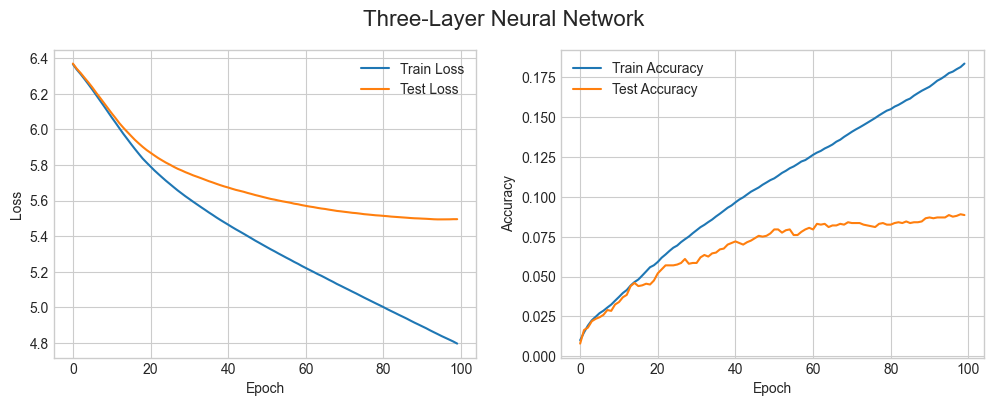

In [44]:
# 0, 1 normalization
input_size = X_train_flat.shape[1]
hidden_size_1 = 512
hidden_size_2 = 256
hidden_size_3 = 128
output_size = Y_test_bin.shape[1]
learning_rate = 0.001
l2_lambda = 0.001
epochs = 100
batch_size = 50

model = heThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
model.train(X_train_flat2, Y_train_bin, X_test_flat2, Y_test_bin, epochs, batch_size)

Epoch 1/100 - Train Loss: 6.3368, Train Accuracy: 1.4200%, Test Loss: 6.3621, Test Accuracy: 1.1600%
Epoch 2/100 - Train Loss: 6.2691, Train Accuracy: 2.1738%, Test Loss: 6.3116, Test Accuracy: 1.7500%
Epoch 3/100 - Train Loss: 6.2146, Train Accuracy: 2.7412%, Test Loss: 6.2749, Test Accuracy: 2.2750%
Epoch 4/100 - Train Loss: 6.1627, Train Accuracy: 3.3175%, Test Loss: 6.2413, Test Accuracy: 2.6700%
Epoch 5/100 - Train Loss: 6.1107, Train Accuracy: 3.9200%, Test Loss: 6.2075, Test Accuracy: 2.9550%
Epoch 6/100 - Train Loss: 6.0584, Train Accuracy: 4.5512%, Test Loss: 6.1737, Test Accuracy: 3.3550%
Epoch 7/100 - Train Loss: 6.0056, Train Accuracy: 5.1113%, Test Loss: 6.1407, Test Accuracy: 3.7850%
Epoch 8/100 - Train Loss: 5.9528, Train Accuracy: 5.6825%, Test Loss: 6.1081, Test Accuracy: 4.0400%
Epoch 9/100 - Train Loss: 5.9005, Train Accuracy: 6.2212%, Test Loss: 6.0768, Test Accuracy: 4.2700%
Epoch 10/100 - Train Loss: 5.8486, Train Accuracy: 6.7988%, Test Loss: 6.0465, Test Accurac

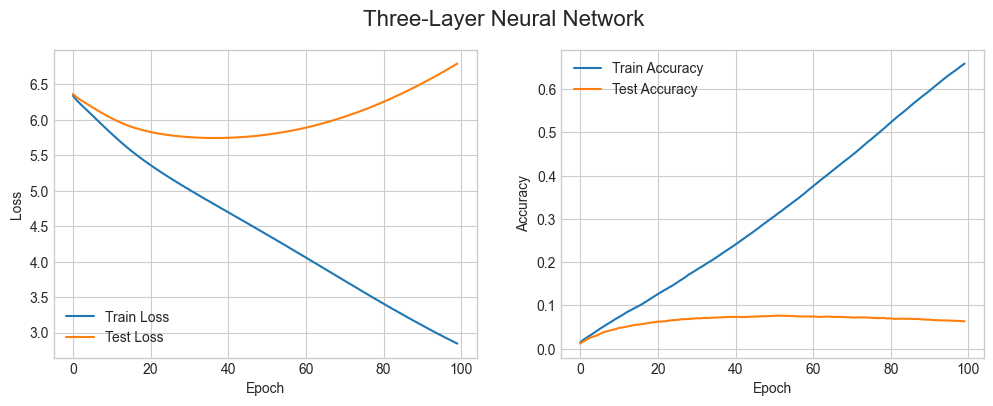

In [45]:
# -1, 1 normalization
input_size = X_train_flat.shape[1]
hidden_size_1 = 512
hidden_size_2 = 256
hidden_size_3 = 128
output_size = Y_test_bin.shape[1]
learning_rate = 0.001
l2_lambda = 0.001
epochs = 100
batch_size = 50

model = heThreeLayerNN(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, learning_rate, l2_lambda)
model.train(X_train_flat3, Y_train_bin, X_test_flat3, Y_test_bin, epochs, batch_size)